In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Display all columns
pd.set_option('display.max_columns', None)

# Set visualization style
sns.set_style("whitegrid")

In [3]:
# ============================================
# LOAD DATASET
# ============================================

df = pd.read_csv("/content/sales.csv")
print(df)
print("Dataset Loaded Successfully")

              id        date  store_nbr       family    sales  onpromotion
0              0  2013-01-01        1.0   AUTOMOTIVE    0.000          0.0
1              1  2013-01-01        1.0    BABY CARE    0.000          0.0
2              2  2013-01-01        1.0       BEAUTY    0.000          0.0
3              3  2013-01-01        1.0    BEVERAGES    0.000          0.0
4              4  2013-01-01        1.0        BOOKS    0.000          0.0
...          ...         ...        ...          ...      ...          ...
1751085  1751085  2015-09-12       41.0  CELEBRATION   14.000          1.0
1751086  1751086  2015-09-12       41.0     CLEANING  955.000          4.0
1751087  1751087  2015-09-12       41.0        DAIRY  515.000          3.0
1751088  1751088  2015-09-12       41.0         DELI  186.219          0.0
1751089  1751089          20        NaN          NaN      NaN          NaN

[1751090 rows x 6 columns]
Dataset Loaded Successfully


In [4]:
print("\nFIRST 5 ROWS")
print(df.head())

print("\nDATASET SHAPE")
print(df.shape)

print("\nCOLUMN NAMES")
print(df.columns)

print("\nDATA TYPES")
print(df.dtypes)

print("\nDATASET INFO")
print(df.info())


FIRST 5 ROWS
   id        date  store_nbr      family  sales  onpromotion
0   0  2013-01-01        1.0  AUTOMOTIVE    0.0          0.0
1   1  2013-01-01        1.0   BABY CARE    0.0          0.0
2   2  2013-01-01        1.0      BEAUTY    0.0          0.0
3   3  2013-01-01        1.0   BEVERAGES    0.0          0.0
4   4  2013-01-01        1.0       BOOKS    0.0          0.0

DATASET SHAPE
(1751090, 6)

COLUMN NAMES
Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion'], dtype='object')

DATA TYPES
id               int64
date            object
store_nbr      float64
family          object
sales          float64
onpromotion    float64
dtype: object

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1751090 entries, 0 to 1751089
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    float64
 3   family       object 
 4   sales        float64
 5   onpromotion  flo


MISSING VALUES
id             0
date           0
store_nbr      1
family         1
sales          1
onpromotion    1
dtype: int64


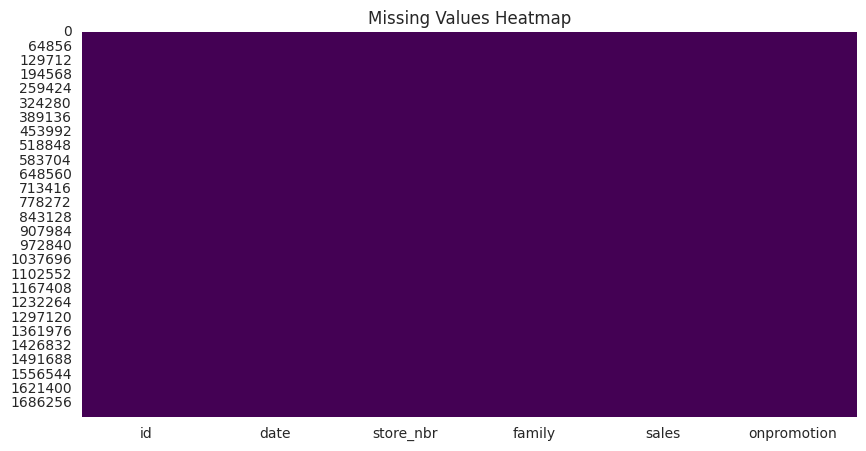

In [7]:
# ============================================
# CHECK MISSING VALUES
# ============================================

print("\nMISSING VALUES")
print(df.isnull().sum())

# Visualize missing values
plt.figure(figsize=(10,5))

sns.heatmap(df.isnull(),
            cbar=False,
            cmap='viridis')

plt.title("Missing Values Heatmap")

plt.show()

In [11]:
# ============================================
# DATA CLEANING
# ============================================
# Safe datetime conversion

df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Check null dates created due to invalid values
print(df['date'].isnull().sum())

# Remove invalid date rows
df = df.dropna(subset=['date'])

# Check duplicates
duplicates = df.duplicated().sum()

print("\nDuplicate Rows:", duplicates)

1

Duplicate Rows: 0


In [12]:
print(df.dtypes)

id                      int64
date           datetime64[ns]
store_nbr             float64
family                 object
sales                 float64
onpromotion           float64
dtype: object


In [14]:
# ============================================
# FEATURE ENGINEERING
# ============================================

# Extract year
df['year'] = df['date'].dt.year

# Extract month
df['month'] = df['date'].dt.month

# Extract month name
df['month_name'] = df['date'].dt.month_name()

# Extract day
df['day'] = df['date'].dt.day

# Extract weekday
df['weekday'] = df['date'].dt.day_name()

print(df.head())

   id       date  store_nbr      family  sales  onpromotion  year  month  \
0   0 2013-01-01        1.0  AUTOMOTIVE    0.0          0.0  2013      1   
1   1 2013-01-01        1.0   BABY CARE    0.0          0.0  2013      1   
2   2 2013-01-01        1.0      BEAUTY    0.0          0.0  2013      1   
3   3 2013-01-01        1.0   BEVERAGES    0.0          0.0  2013      1   
4   4 2013-01-01        1.0       BOOKS    0.0          0.0  2013      1   

  month_name  day  weekday  
0    January    1  Tuesday  
1    January    1  Tuesday  
2    January    1  Tuesday  
3    January    1  Tuesday  
4    January    1  Tuesday  


In [15]:
# ============================================
# DESCRIPTIVE STATISTICS
# ============================================

print("\nDESCRIPTIVE STATISTICS")
print(df['sales'].describe())

# Mean
mean_sales = df['sales'].mean()

# Median
median_sales = df['sales'].median()

# Mode
mode_sales = df['sales'].mode()[0]

print("\nMEAN SALES:", mean_sales)
print("MEDIAN SALES:", median_sales)
print("MODE SALES:", mode_sales)

# Variance
print("VARIANCE:", df['sales'].var())

# Standard Deviation
print("STANDARD DEVIATION:", df['sales'].std())


DESCRIPTIVE STATISTICS
count    1.751089e+06
mean     2.871771e+02
std      9.155428e+02
min      0.000000e+00
25%      0.000000e+00
50%      4.000000e+00
75%      1.510000e+02
max      4.627100e+04
Name: sales, dtype: float64

MEAN SALES: 287.17711009876894
MEDIAN SALES: 4.0
MODE SALES: 0.0
VARIANCE: 838218.6746148551
STANDARD DEVIATION: 915.542830573674


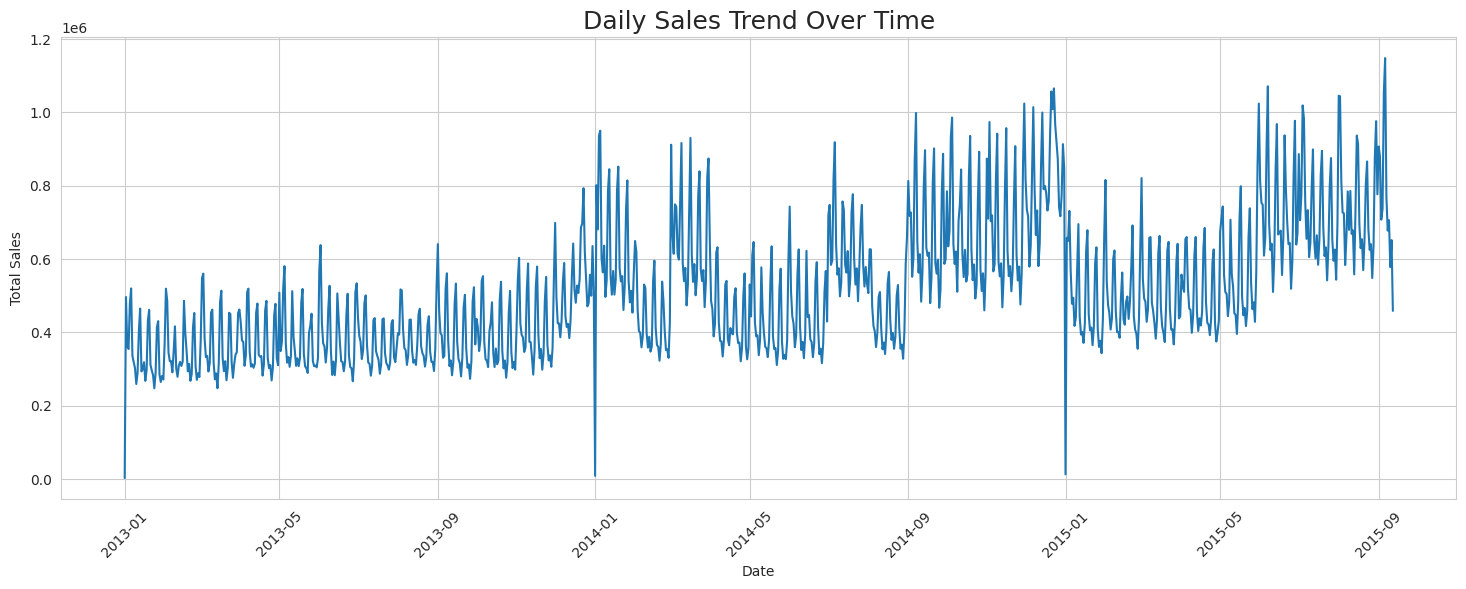

In [16]:
# ============================================
# SALES TREND OVER TIME
# ============================================

daily_sales = df.groupby('date')['sales'].sum()

plt.figure(figsize=(18,6))

plt.plot(daily_sales.index,
         daily_sales.values)

plt.title("Daily Sales Trend Over Time",
          fontsize=18)

plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

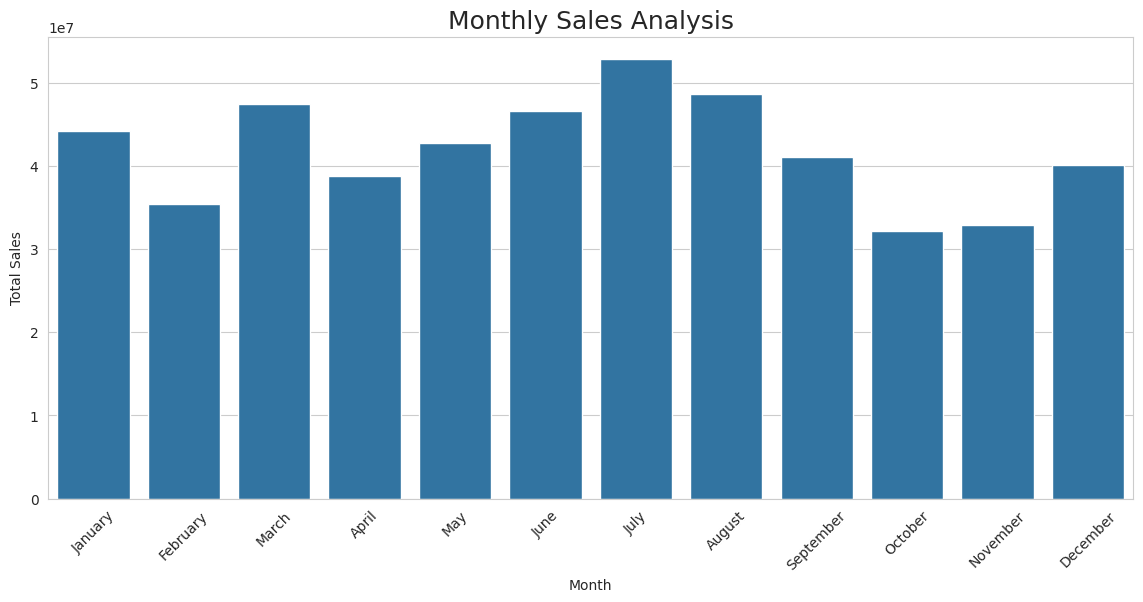

In [17]:
# ============================================
# MONTHLY SALES ANALYSIS
# ============================================

monthly_sales = df.groupby('month_name')['sales'].sum()

# Proper month order
month_order = ['January', 'February', 'March',
               'April', 'May', 'June',
               'July', 'August', 'September',
               'October', 'November', 'December']

monthly_sales = monthly_sales.reindex(month_order)

plt.figure(figsize=(14,6))

sns.barplot(x=monthly_sales.index,
            y=monthly_sales.values)

plt.title("Monthly Sales Analysis",
          fontsize=18)

plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

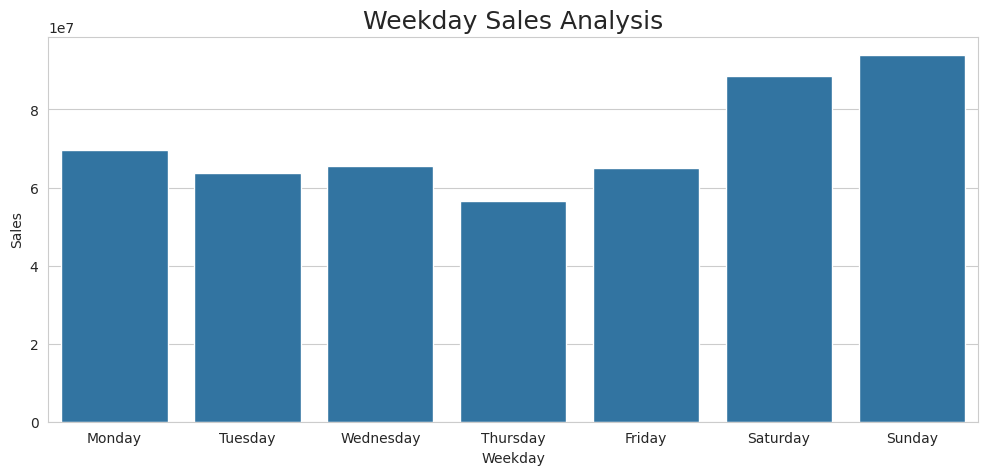

In [18]:
# ============================================
# WEEKDAY SALES ANALYSIS
# ============================================

weekday_sales = df.groupby('weekday')['sales'].sum()

weekday_order = ['Monday',
                 'Tuesday',
                 'Wednesday',
                 'Thursday',
                 'Friday',
                 'Saturday',
                 'Sunday']

weekday_sales = weekday_sales.reindex(weekday_order)

plt.figure(figsize=(12,5))

sns.barplot(x=weekday_sales.index,
            y=weekday_sales.values)

plt.title("Weekday Sales Analysis",
          fontsize=18)

plt.xlabel("Weekday")
plt.ylabel("Sales")

plt.show()

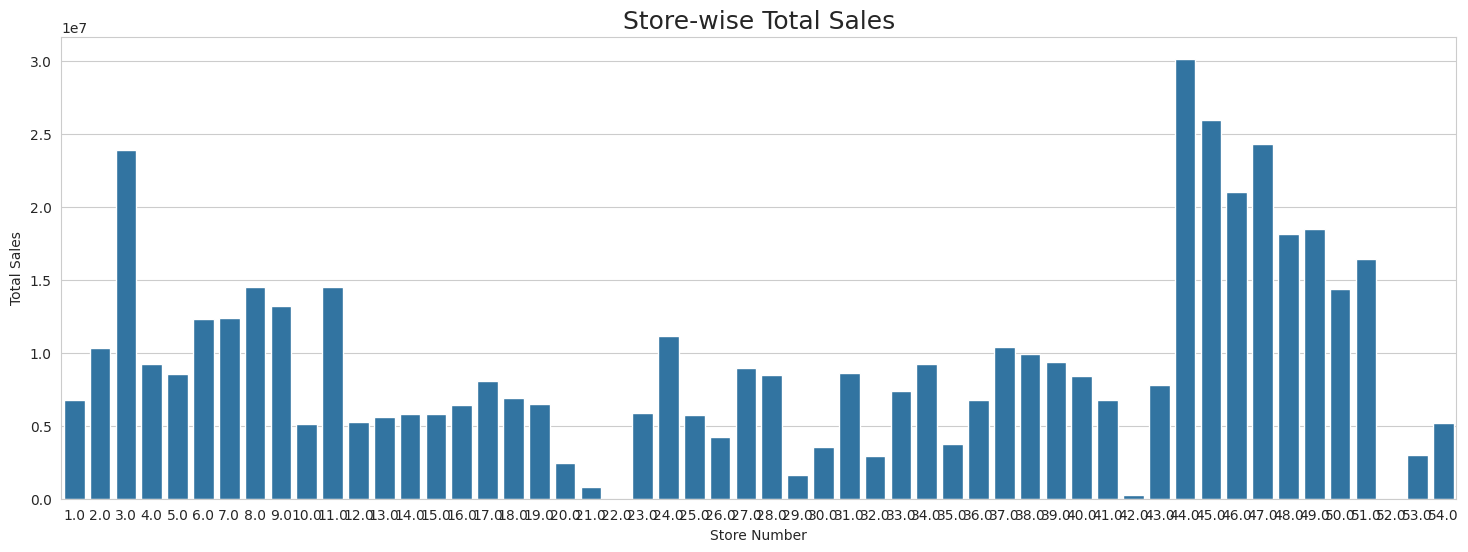

In [19]:
# ============================================
# STORE-WISE SALES ANALYSIS
# ============================================

store_sales = df.groupby('store_nbr')['sales'].sum()

plt.figure(figsize=(18,6))

sns.barplot(x=store_sales.index,
            y=store_sales.values)

plt.title("Store-wise Total Sales",
          fontsize=18)

plt.xlabel("Store Number")
plt.ylabel("Total Sales")

plt.show()

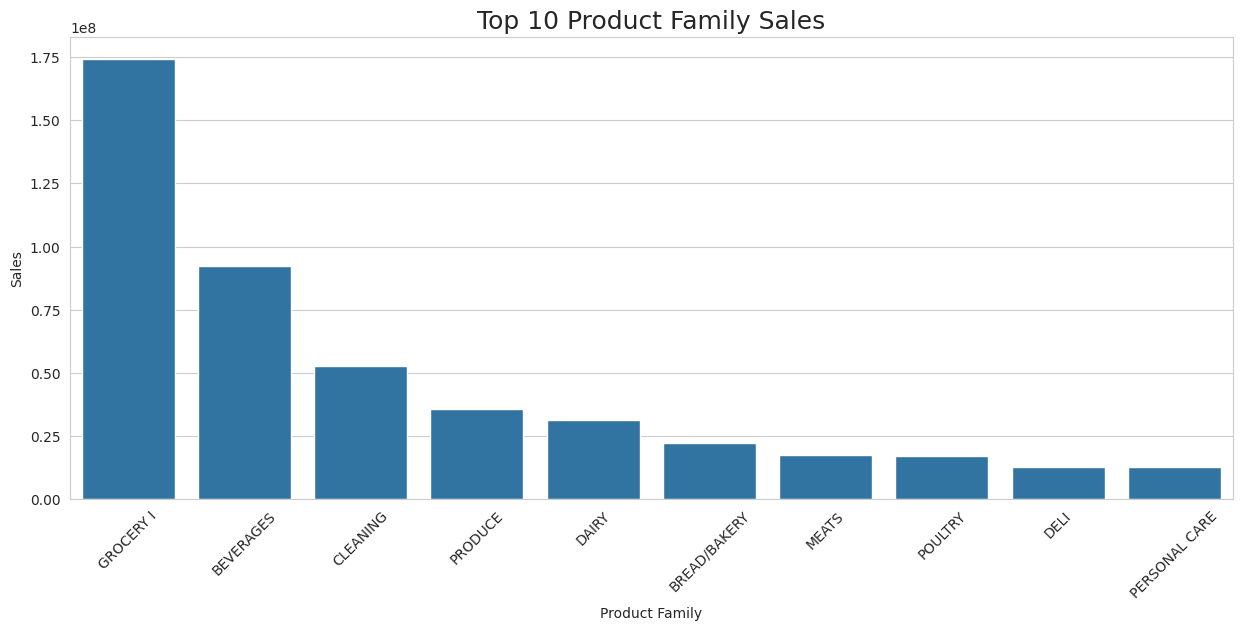

In [20]:
# ============================================
# PRODUCT FAMILY ANALYSIS
# ============================================

family_sales = df.groupby('family')['sales'].sum()

top_family = family_sales.sort_values(ascending=False).head(10)

plt.figure(figsize=(15,6))

sns.barplot(x=top_family.index,
            y=top_family.values)

plt.title("Top 10 Product Family Sales",
          fontsize=18)

plt.xlabel("Product Family")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

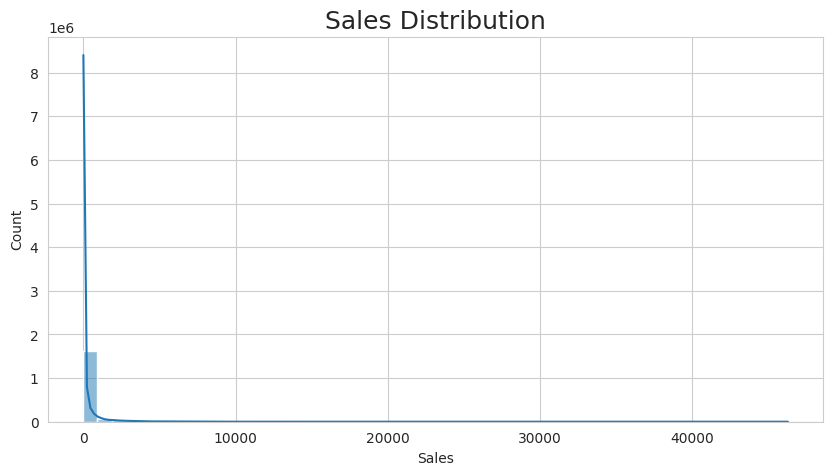

In [21]:
# ============================================
# SALES DISTRIBUTION
# ============================================

plt.figure(figsize=(10,5))

sns.histplot(df['sales'],
             bins=50,
             kde=True)

plt.title("Sales Distribution",
          fontsize=18)

plt.xlabel("Sales")

plt.show()

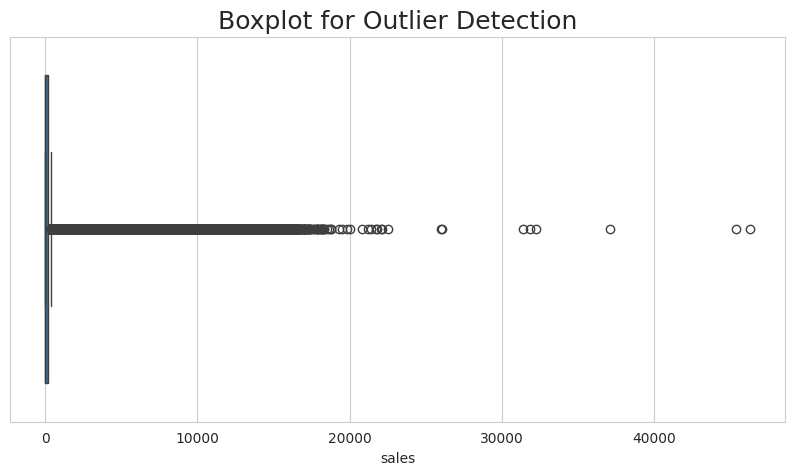

In [22]:
# ============================================
# OUTLIER DETECTION
# ============================================

plt.figure(figsize=(10,5))

sns.boxplot(x=df['sales'])

plt.title("Boxplot for Outlier Detection",
          fontsize=18)

plt.show()

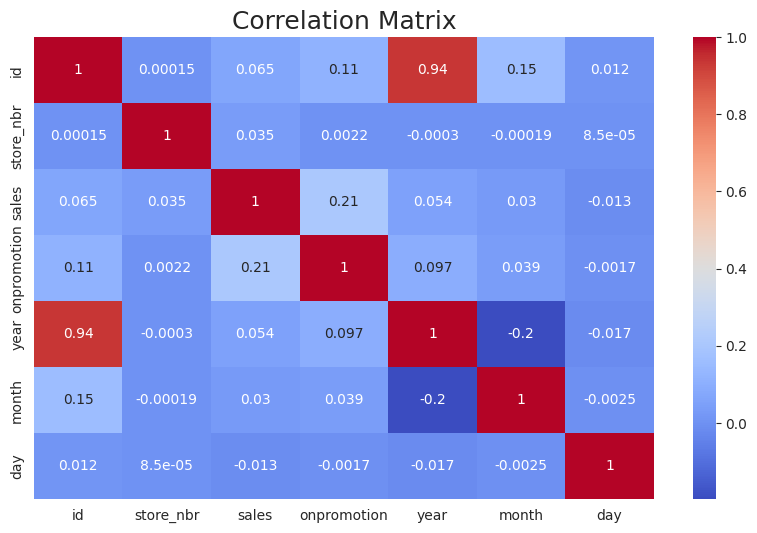

In [23]:
# ============================================
# CORRELATION ANALYSIS
# ============================================

numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

plt.figure(figsize=(10,6))

sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix",
          fontsize=18)

plt.show()

In [25]:
# ============================================
# TOP 10 STORES
# ============================================

top_stores = store_sales.sort_values(ascending=False).head(10)

print("\nTOP 10 STORES")

print(top_stores.apply(lambda x: f"{x:,.2f}"))


TOP 10 STORES
store_nbr
44.0    30,157,244.28
45.0    25,975,147.52
47.0    24,325,607.56
3.0     23,900,095.55
46.0    21,026,203.84
49.0    18,514,075.36
48.0    18,124,599.30
51.0    16,400,230.22
11.0    14,541,617.34
8.0     14,525,318.22
Name: sales, dtype: object


In [26]:
# ============================================
# SAVE CLEANED DATA
# ============================================

df.to_csv("cleaned_sales_data.csv",
          index=False)

print("\nCleaned dataset saved successfully.")


Cleaned dataset saved successfully.
